In [ ]:
import xarray as xr
import numpy as np

from scipy.interpolate import RegularGridInterpolator

import matplotlib.pyplot as plt
import matplotlib.colors as colors
import cmocean.cm as cmo
plt.style.use('/mnt/c/Ryan_Data/Python_Tool/ryan_mplstyle.mplstyle')

OSError: '/mnt/c/Ryan_Data/Python_Tool/ryan_mplstyle.mplstyle' is not a valid package style, path of style file, URL of style file, or library style name (library styles are listed in `style.available`)

In [2]:
ds = xr.open_dataset("data/data_channel/channel_snap.nc")

In [3]:
ds

<xarray.Dataset> Size: 2GB
Dimensions:              (YC: 800, XC: 800, Z: 76, Zp1: 77, XG: 800, YG: 800,
                          Zl: 76, Zu: 76, layer_1TH_bounds: 43,
                          layer_1TH_center: 42, layer_1TH_interface: 41)
Coordinates: (12/32)
    Depth                (YC, XC) float32 3MB ...
    PHrefC               (Z) float32 304B ...
    PHrefF               (Zp1) float32 308B ...
  * XC                   (XC) float32 3kB 500.0 1.5e+03 ... 7.985e+05 7.995e+05
  * XG                   (XG) float32 3kB 0.0 1e+03 2e+03 ... 7.98e+05 7.99e+05
  * YC                   (YC) float32 3kB 6.005e+05 6.015e+05 ... 1.4e+06
    ...                   ...
    maskW                (Z, YC, XG) bool 49MB ...
    rA                   (YC, XC) float32 3MB ...
    rAs                  (YG, XC) float32 3MB ...
    rAw                  (YC, XG) float32 3MB ...
    rAz                  (YG, XG) float32 3MB ...
    time                 timedelta64[ns] 8B ...
Data variables:
    Eta                  (YC, XC) float32 3MB ...
    PH                   (Z, YC, XC) float32 195MB ...
    PTRACER01            (Z, YC, XC) float32 195MB ...
    T                    (Z, YC, XC) float32 195MB ...
    U                    (Z, YC, XG) float32 195MB ...
    V                    (Z, YG, XC) float32 195MB ...
    W                    (Zl, YC, XC) float32 195MB ...

In [4]:
# Eta_ds = ds.Eta.values

f = 2*7.2921e-5*np.sin(-35*np.pi/180)
g = 9.81

In [5]:
dui_km = 1

XC_2k = (ds.XC[0:400].values)
# YC_2k = (ds.YC[200:600].values)-8e5
YC_2k = (ds.YC[0:400].values)-6e5
XC_ui,YC_ui = np.meshgrid(XC_2k,YC_2k)
print(XC_2k.shape)

(400,)


In [ ]:
def interp_to_reggrid(input_data,x_loc,y_loc):
    interp = RegularGridInterpolator(( x_loc, y_loc ), input_data.values.T  ,bounds_error=False, fill_value=None)
    temp = interp((XC_ui,YC_ui))
    return temp

# Use default scipy interp here, maybe try spline, for derivatives

In [ ]:
# Go from MITgcm-grid to the center

U_surface = ds.U[0,:,:]
U_surface = interp_to_reggrid(U_surface,ds.XG, ds.YC-6e5)

V_surface = ds.V[0,:,:]
V_surface = interp_to_reggrid(V_surface,ds.XC, ds.YG-6e5)

In [ ]:
# Take first derivative and put onto the center

Uxdif = ds.U.differentiate("XG");  
Uxdif = Uxdif.assign_coords(XG=ds.XC.values); Uxdif = Uxdif.rename({"XG":"XC"})
Uxdif_surface = Uxdif[0,:,:]
Uxdif_surface = interp_to_reggrid(Uxdif_surface,ds.XC, ds.YC-6e5)

Vydif = ds.V.differentiate("YG");  
Vydif = Vydif.assign_coords(YG=ds.YC.values); Vydif = Vydif.rename({"YG":"YC"})
Vydif_surface = Vydif[0,:,:]
Vydif_surface = interp_to_reggrid(Vydif_surface,ds.XC, ds.YC-6e5)

Vxdif = ds.V.differentiate("XC");  
Vxdif = Vxdif.assign_coords(XC=ds.XG.values); Vxdif = Vxdif.rename({"XC":"XG"})
Vxdif_surface = Vxdif[0,:,:]
Vxdif_surface = interp_to_reggrid(Vxdif_surface,ds.XG, ds.YG-6e5)

Uydif = ds.U.differentiate("YC");  
Uydif = Uydif.assign_coords(YC=ds.YG.values); Uydif = Uydif.rename({"YC":"YG"})
Uydif_surface = Uydif[0,:,:]
Uydif_surface = interp_to_reggrid(Uydif_surface,ds.XG, ds.YG-6e5)

In [ ]:
div_surface  = (Uxdif_surface+Vydif_surface)/np.abs(f)
zeta_surface = (-Uydif_surface+Vxdif_surface)/f
strain_surface = np.sqrt( (Uxdif_surface-Vydif_surface)**2+(Vxdif_surface+Uydif_surface)**2 )/np.abs(f)

# This line prob does nothing
Eta = interp_to_reggrid(ds.Eta,ds.XC, ds.YC-6e5)

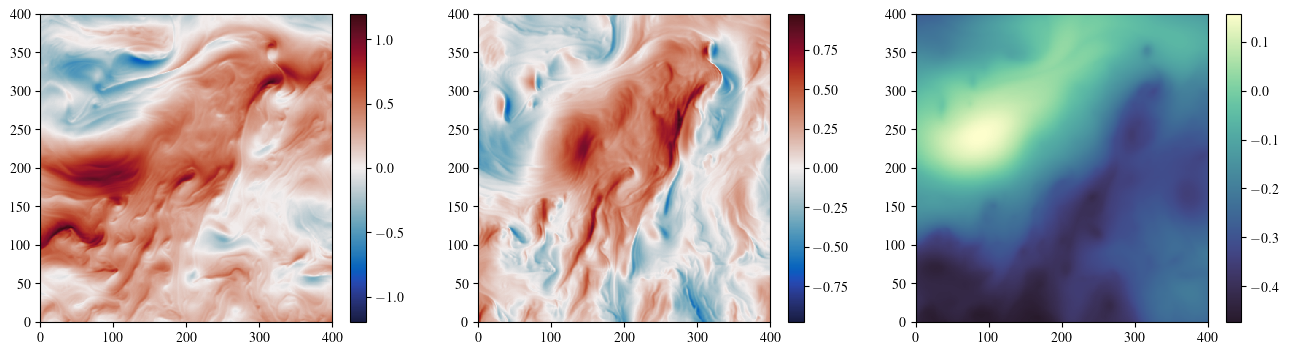

In [10]:
plt.figure(figsize=(16,4.0))

plt.subplot(131)
plt.pcolor(XC_ui/1e3,YC_ui/1e3,U_surface, cmap=cmo.balance, norm=colors.CenteredNorm())

plt.colorbar()

plt.subplot(132)
plt.pcolor(XC_ui/1e3,YC_ui/1e3,V_surface, cmap=cmo.balance, norm=colors.CenteredNorm())
plt.colorbar()

plt.subplot(133)
plt.pcolor(XC_ui/1e3,YC_ui/1e3,Eta, cmap=cmo.deep_r)
plt.colorbar()

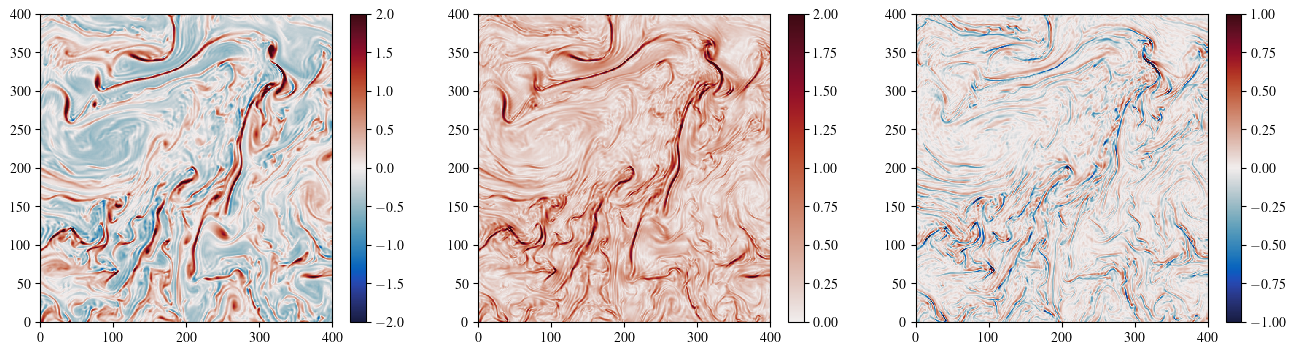

In [11]:
plt.figure(figsize=(16,4.0))

plt.subplot(131)
plt.pcolor(XC_ui/1e3,YC_ui/1e3,zeta_surface, cmap=cmo.balance, vmin=-2, vmax=2)

plt.colorbar()

plt.subplot(132)
plt.pcolor(XC_ui/1e3,YC_ui/1e3,strain_surface, cmap=cmo.amp, vmin=0, vmax=2)
plt.colorbar()

plt.subplot(133)
plt.pcolor(XC_ui/1e3,YC_ui/1e3,div_surface, cmap=cmo.balance, vmin=-1, vmax=1)
plt.colorbar()

(400, 400)
(400, 400)


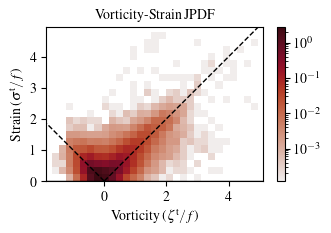

In [12]:
zetat_all = zeta_surface
# zetat_all = zrel
straint_all = strain_surface

print(zetat_all.shape)
print(straint_all.shape)

zmax = np.max(zetat_all[:,:].ravel())+1e-10
zmin = np.min(zetat_all[:,:].ravel())

z_range = np.linspace(zmin,zmax,30)
s_range = np.arange(0,zmax,z_range[-1]-z_range[-2])

fig=plt.figure(figsize=(3.5, 2.0))

plt.hist2d(zetat_all.ravel(),straint_all.ravel(), density=True, bins=[z_range, s_range], cmap=cmo.amp, norm=colors.LogNorm())
axs_max = max(abs(zetat_all.ravel()))
plt.plot([0,axs_max],[0,axs_max],'--',color='k'); plt.plot([0,-axs_max],[0,axs_max],'--',color='k'); plt.axhline(0,color='k')
plt.axis('equal'); 
plt.xlim(min(zetat_all.ravel()),max(zetat_all.ravel()))
plt.colorbar()
plt.title('Vorticity-Strain JPDF')
plt.xlabel("Vorticity ($\zeta^\mathrm{t}/f$)")
plt.ylabel("Strain ($\sigma^\mathrm{t}/f$)")

plt.show()

In [ ]:
# Saving as xarray

d_save = xr.Dataset(
    
    # dims=["x", "y"],
    coords=dict(
        x=(["x", "y"], XC_ui),
        y=(["x", "y"], YC_ui),
    ),
)

d_save["U_surface"]=(["x", "y"],  U_surface)
d_save["V_surface"]=(["x", "y"],  V_surface)
d_save["Eta"]=(["x", "y"],  Eta)
d_save["zeta_surface"]=(["x", "y"],  zeta_surface)
d_save["strain_surface"]=(["x", "y"],  strain_surface)
d_save["div_surface"]=(["x", "y"],  div_surface)
d_save["f"]=(f)
d_save["g"]=(g)

In [14]:
d_save

<xarray.Dataset> Size: 9MB
Dimensions:         (x: 400, y: 400)
Coordinates:
    x               (x, y) float32 640kB 500.0 1.5e+03 ... 3.985e+05 3.995e+05
    y               (x, y) float32 640kB 500.0 500.0 ... 3.995e+05 3.995e+05
Data variables:
    U_surface       (x, y) float64 1MB 0.3046 0.288 0.2328 ... -0.1343 -0.1229
    V_surface       (x, y) float64 1MB 0.5964 0.6263 0.5538 ... 0.238 0.2402
    Eta             (x, y) float64 1MB -0.427 -0.4318 ... -0.1284 -0.1293
    zeta_surface    (x, y) float64 1MB -0.0567 0.7763 1.421 ... 0.07465 0.07486
    strain_surface  (x, y) float64 1MB 0.2256 0.6753 1.415 ... 0.293 0.3092
    div_surface     (x, y) float64 1MB 0.2013 -0.03911 ... -0.01882 -0.008236
    f               float64 8B -8.365e-05
    g               float64 8B 9.81

In [15]:
d_save.to_netcdf('data/data_channel/processed/truth.nc')